In [2403]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

# PBL 1

5 days
1 minute

Component Abbreviations:
- B = bacterial concentration (streptococcus pyogenes)
- A = antibiotic concentration (amoxicillin)
- N = neutrophil concentration
- I = antibody concentration (IgG)

Compartment Abbreviations:
- epi = epithelial cell surface
- lym = lymphatic system
- cir = circulatory system
- sto = stomach
- bone = bone marrow

Other Abbreviations:
- pro = proliferation/production rate
- elim = death/clearance/elimination rate
- t = transfer rate
- abs = absorption rate

## Variables:

### Inputs:

In [2404]:
hasAntibiotics = True # whether to include amoxicillin treatment in the model

neutropeniaMult = 1 # multiplier for neutrophil proliferation rate to simulate neutropenia (e.g., 0.5 for 50% reduction)

### Initial Conditions:

In [2405]:
epiB0 = 1e4 # initial bacterial concentration on epithelial cell surface (CFU/mL)
cirN0 = 5e6 # initial neutrophil concentration in circulatory system (cells/mL)

### Constants:

In [2406]:
# Bacteria:
proB = np.log(2) / 1 # bacterial proliferation rate
elimBfromA = 0.716 # bacterial death rate due to amoxicillin
elimBfromN = 0.82 # initial bacterial death rate due to neutrophils
elimBfromI = 0.223 # bacterial death rate due to antibodies
tBEpitoLym = 0.02 # transfer rate of bacteria from epithelial cell surface to lymphatic system
kB = 1e10 # maximum capacity of bacteria in the system (CFU/mL)

# Amoxicillin:
doseA = 0.8 * 500 / 5000 if hasAntibiotics else 0 # standard dose of amoxicillin (mg)
absA = 0.4 # absorption rate of amoxicillin
elimA = 2.5 # elimination rate of amoxicillin
filA = 1.16 # filtration rate of amoxicillin by kidneys
tACirtoLym = 0.92 # transfer rate of amoxicillin from circulatory system to lymphatic system
tALymtoCir = 1.99 # transfer rate of amoxicillin from lymphatic system to circulatory system
tACirtoEpi = 0.82 # transfer rate of amoxicillin from circulatory system to epithelial cell surface
tAEpitoCir = 4.42 # transfer rate of amoxicillin from epithelial cell surface to circulatory system
ec50A = 0.016 * 0.001 # half-maximal effective concentration of amoxicillin (mg/mL)

# Neutrophils:
proNbase = 7.5e10 / (24 * 5000) * neutropeniaMult # average neutrophil proliferation rate (cells/mL/hr)
proNmax = 1e11 / (24 * 5000) * neutropeniaMult # maximum neutrophil proliferation rate (cells/mL/hr)
elimN = np.log(2) / 15 # neutrophil death rate (half-life of 15 hours)
tNCirtoLym = 0.0077 # transfer rate of neutrophils from circulatory system to lymphatic system
tNLymtoCir = 0.0077 # transfer rate of neutrophils from lymphatic system to circulatory system
tNCirtoEpi = 0.0077 # transfer rate of neutrophils from circulatory system to epithelial cell surface
tNEpitoCir = 0.0077 # transfer rate of neutrophils from epithelial cell surface to circulatory system
ec50N = 1.19e6 # half-maximal effective concentration of neutrophils (cells/mL)
pro50N = 1e4 # bacterial concentration at which neutrophil production is half-maximal (CFU/mL)

# Antibodies:
proI = 0.0000228 # antibody production rate (mg/mL/hr)
elimI = np.log(2) / (7 * 24) # antibody elimination rate (half-life of 7 days)
tILymtoCir = 0.12 / 6 # transfer rate of antibodies from lymphatic system to circulatory system
tICirtoLym = 0.737 / 24 # transfer rate of antibodies from circulatory system to lymphatic system
tIEpitoCir = 0.737 / 24 # transfer rate of antibodies from epithelial cell surface to circulatory
tICirtoEpi = tIEpitoCir # transfer rate of antibodies from circulatory system to epithelial cell surface
ec50I = 0.0002 # half-maximal effective concentration of antibodies (mg/mL)
pro50I = 1e7 # bacterial concentration at which antibody production is half-maximal (CFU/mL)
t50I = 72 # time at which antibody production reaches half-maximal level (hours)

## Kinetics Equations:

In [2407]:
# Hill function for saturation kinetics (e.g., drug effect, immune response)
def hill(x, k):
    return x / (k + x)

# Hill function for impulse kinetics (e.g., time-dependent antibody production)
def hillImpulse(x, k):
    return x**5 / (k**5 + x**5)

# Logistic growth function for bacterial proliferation with carrying capacity
def logistic(x, r, K):
    return r * x * (1 - x / K)

## Rate Equations:

### Bacterial Rate Equations:

In [2408]:
# rate equation for bacteria in the lymphatic system
def dBdtLym(_lymB, _lymA, _lymN, _lymI, _epiB):
    return (logistic(_lymB, proB, kB)
            - elimBfromA * hill(_lymA, ec50A) * _lymB
            - elimBfromN * hill(_lymN, ec50N) * _lymB
            - elimBfromI * hill(_lymI, ec50I) * _lymB
            + tBEpitoLym * _epiB)

# rate equation for bacteria on the epithelial cell surface
def dBdtEpi(_epiB, _epiA, _epiN, _epiI):
    return (logistic(_epiB, proB, kB)
            - elimBfromA * hill(_epiA, ec50A) * _epiB
            - elimBfromN * hill(_epiN, ec50N) * _epiB
            - elimBfromI * hill(_epiI, ec50I) * _epiB
            - tBEpitoLym * _epiB)

### Amoxicillin Rate Equations:

In [2409]:
# rate equation for amoxicillin in the circulatory system
def dAdtCir(_digA, _cirA, _lymA, _epiA):
    return (absA * _digA - elimA * _cirA
           + tALymtoCir * _lymA
           - tACirtoLym * _cirA
           + tAEpitoCir * _epiA
           - tACirtoEpi * _cirA) if hasAntibiotics else 0

# rate equation for amoxicillin in the lymphatic system
def dAdtLym(_cirA, _lymA): return tACirtoLym * _cirA - tALymtoCir * _lymA - elimA * _lymA if hasAntibiotics else 0

# rate equation for amoxicillin on the epithelial cell surface
def dAdtEpi(_cirA, _epiA): return tACirtoEpi * _cirA - tAEpitoCir * _epiA - elimA * _epiA if hasAntibiotics else 0

### Neutrophil Rate Equations:

In [2410]:
# rate equation for neutrophils in the circulatory system
def dNdtCir(_epiB, _cirN, _lymN, _epiN):
    return (max(proNbase, proNmax * hill(_epiB, pro50N)) - elimN * (_cirN - cirN0)
           + tNLymtoCir * _lymN
           - tNCirtoLym * _cirN
           + tNEpitoCir * _epiN
           - tNCirtoEpi * _cirN)

# rate equation for neutrophils in the lymphatic system
def dNdtLym(_lymN, _cirN, _epiN): return tNCirtoLym * _cirN - tNLymtoCir * _lymN - elimN * _lymN

# rate equation for neutrophils on the epithelial cell surface
def dNdtEpi(_epiN, _cirN): return tNCirtoEpi * _cirN - tNEpitoCir * _epiN - elimN * _epiN

### Antibody Rate Equations:

In [2411]:
# rate equation for antibodies in the circulatory system
def dIdtCir(_cirI, _lymI, _epiI):
    return (tILymtoCir * _lymI
            - tICirtoLym * _cirI
            + tICirtoEpi * _cirI
            - tIEpitoCir * _epiI
            - elimI * _cirI)

# rate equation for antibodies in the lymphatic system
def dIdtLym(_t, _lymI, _epiB, _cirI):
    return (proI * hill(_epiB, pro50I) * hillImpulse(_t, t50I) - elimI * _lymI
            + tICirtoLym * _cirI
            - tILymtoCir * _lymI)

# rate equation for antibodies on the epithelial cell surface
def dIdtEpi(_cirI, _epiI):
    return tICirtoEpi * _cirI - tIEpitoCir * _epiI - elimI * _epiI

### Digestive Tract Rate Equation:

In [2412]:
# rate equation for amoxicillin in the digestive tract
def dDdt(_digA):
    return -absA * _digA

### Kidney Rate Equation

In [2413]:
# rate equation for amoxicillin in the kidneys
def dKdt(_cirA, _kidA):
    return elimA * _cirA - filA * _kidA

## Total Rate Equation:

In [2414]:
def dYdt(_t, _y):
    _lymB, _epiB, _cirA, _lymA, _epiA, _cirN, _lymN, _epiN, _cirI, _lymI, _epiI, _digA, _kidA = _y

    return ([dBdtLym(_lymB, _lymA, _lymN, _lymI, _epiB),
            dBdtEpi(_epiB, _epiA, _epiN, _epiI),
            dAdtCir(_digA, _cirA, _lymA, _epiA),
            dAdtLym(_cirA, _lymA),
            dAdtEpi(_cirA, _epiA),
            dNdtCir(_epiB, _cirN, _lymN, _epiN),
            dNdtLym(_lymN, _cirN, _epiN),
            dNdtEpi(_epiN, _cirN),
            dIdtCir(_cirI, _lymI, _epiI),
            dIdtLym(_t, _lymI, _epiB, _cirI),
            dIdtEpi(_cirI, _epiI),
            dDdt(_digA),
            dKdt(_cirA, _kidA)])

## Simulation:

In [2415]:
t0, tf = 0.0, 120.0 # time span for 5 days in hours

doseInterval = 12 # hours between doses

y = [0, epiB0, 0, 0, 0, cirN0, 0, 0, 0, 0, 0, 0, 0] # initial conditions for all variables

T = [] # time points
Y = [] # variable values at each time point

t = t0

while t < tf:
    t_next = min(t + doseInterval, tf) if t >= 12 else 12 # next time point for dose or end of simulation
    tPoints = np.arange(t, t_next, 1/60, dtype = float) # time points for ODE solver (every minute)
    sol = scipy.integrate.solve_ivp(dYdt, (t, t_next), y, method='Radau', t_eval = tPoints) # solve the ODEs from current time to next dose time
    T.extend(tPoints) # append time points from the solution
    Y.extend(sol.y.T) # append variable values from the solution (transpose to match time points)

    y = sol.y[:, -1] # get the last values of the variables
    t = t_next # update time to the next dose time

    if t < tf:
        y[11] += doseA # administer another dose of amoxicillin into the digestive tract

Y = np.array(Y) # convert list to array
T = np.array(T) # convert list to array

lymB = Y[:, 0] # bacterial concentration in lymphatic system
epiB = Y[:, 1] # bacterial concentration on epithelial cell surface

cirA = Y[:, 2] # amoxicillin concentration in circulatory system
lymA = Y[:, 3] # amoxicillin concentration in lymphatic system
epiA = Y[:, 4] # amoxicillin concentration on epithelial cell surface
digA = Y[:, 11] # amoxicillin concentration in digestive tract
kidA = Y[:, 12] # amoxicillin concentration in kidneys

cirN = Y[:, 5] # neutrophil concentration in circulatory system
lymN = Y[:, 6] # neutrophil concentration in lymphatic system
epiN = Y[:, 7] # neutrophil concentration on epithelial cell surface

cirI = Y[:, 8] # antibody concentration in circulatory system
lymI = Y[:, 9] # antibody concentration in lymphatic system
epiI = Y[:, 10] # antibody concentration on epithelial cell surface

t = T

## Plots:

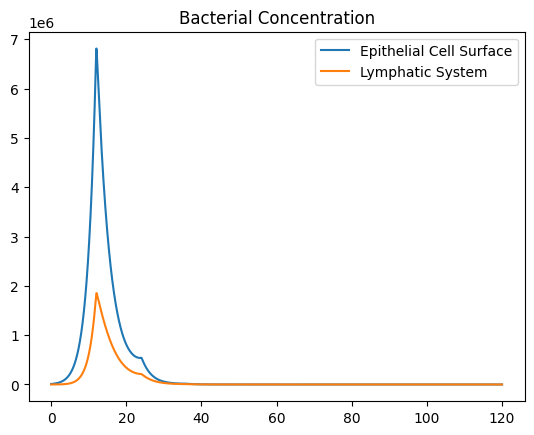

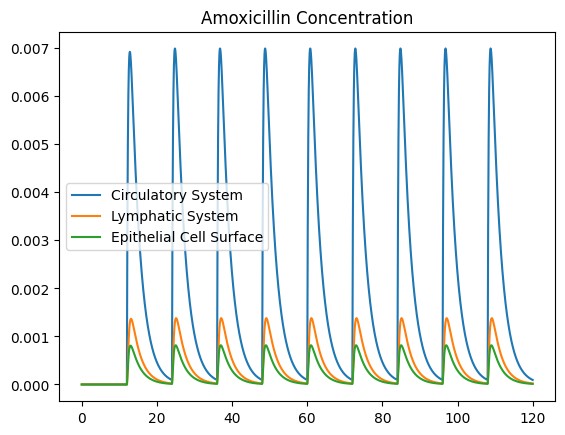

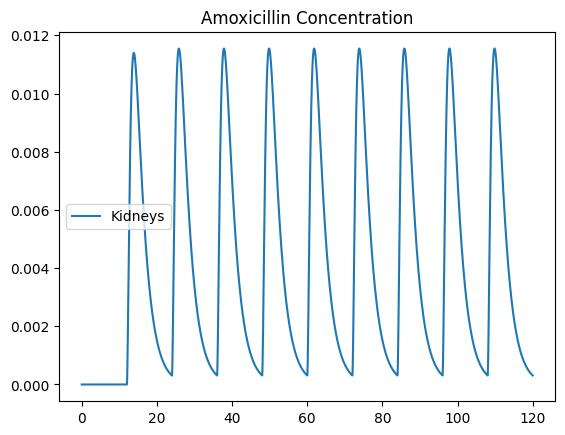

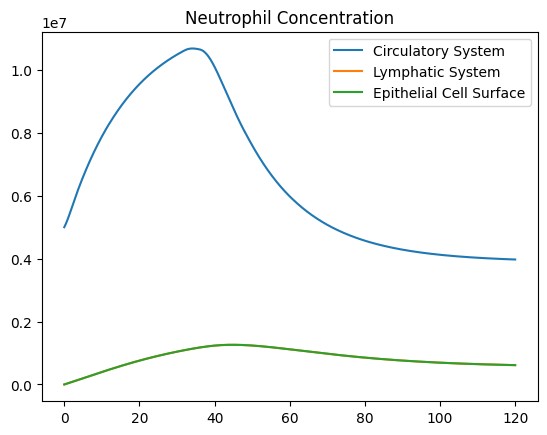

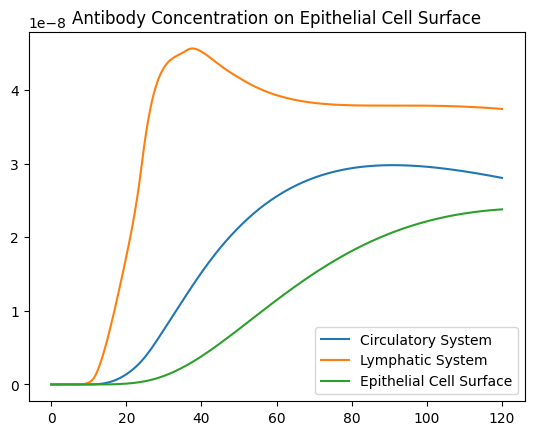

In [2416]:
plt.plot(t, epiB, label='Epithelial Cell Surface')
plt.plot(t, lymB, label='Lymphatic System')
plt.legend()
plt.title('Bacterial Concentration')
plt.show()

plt.plot(t, cirA, label='Circulatory System')
plt.plot(t, lymA, label='Lymphatic System')
plt.plot(t, epiA, label='Epithelial Cell Surface')
plt.legend()
plt.title('Amoxicillin Concentration')
plt.show()

plt.plot(t, kidA, label='Kidneys')
plt.legend()
plt.title('Amoxicillin Concentration')
plt.show()

plt.plot(t, cirN, label='Circulatory System')
plt.plot(t, lymN, label='Lymphatic System')
plt.plot(t, epiN, label='Epithelial Cell Surface')
plt.legend()
plt.title('Neutrophil Concentration')
plt.show()

plt.plot(t, cirI, label='Circulatory System')
plt.plot(t, lymI, label='Lymphatic System')
plt.plot(t, epiI, label='Epithelial Cell Surface')
plt.legend()
plt.title('Antibody Concentration on Epithelial Cell Surface')
plt.show()

T = T.reshape(-1, 1) # reshape time array to be a column vector
data = np.concatenate((T, Y), axis=1)
np.savetxt('base.csv', data, delimiter=',')